In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
import seaborn as sns


 Wygeneruj dane syntetyczne (sklearn.datasets.make_regression, dodaj szum), dopasuj model liniowy, a następnie napisz funkcję plot_residuals(model, X, y), która rysuje wykres reszt względem wartości przewidywanych i ocenia, czy widać heteroskedastyczność.

In [21]:
#dwie cechy i 5 wierszy
X, y = make_regression(n_samples=200, n_features=2, noise=1, random_state=42)


array([[-1.01283112,  0.31424733],
       [ 0.0675282 , -1.42474819],
       [ 1.47789404, -0.51827022],
       [ 0.08704707, -0.29900735],
       [-0.46341769, -0.46572975],
       [-0.22346279,  0.71400049],
       [ 0.82541635,  0.81350964],
       [ 1.15859558, -0.82068232],
       [ 0.91540212,  0.32875111],
       [-3.24126734, -1.02438764],
       [-2.12389572, -0.52575502],
       [-0.2176812 ,  1.09877685],
       [-0.79252074, -0.11473644],
       [-1.00601738, -1.21418861],
       [-0.60063869, -0.29169375],
       [-2.02514259,  0.18645431],
       [ 0.64768854,  1.52302986],
       [ 1.26691115, -0.70766947],
       [-0.77282521, -0.23681861],
       [-0.73036663,  0.21645859],
       [ 1.76545424,  0.40498171],
       [ 0.01300189,  1.45353408],
       [ 0.07580456, -0.67716171],
       [ 1.58601682, -1.2378155 ],
       [ 0.29307247, -0.71435142],
       [-1.1913035 ,  0.65655361],
       [ 0.25049285,  0.34644821],
       [ 0.95042384, -0.57690366],
       [ 0.73846658,

In [22]:
y

array([ -32.71085094,  -34.87474453,   47.04693289,   -4.18012482,
        -32.09922998,   11.77473038,   56.87626081,   25.82623282,
         47.63062547, -163.67258925, -102.14418874,   20.57893715,
        -36.67490504,  -73.72712437,  -31.33962567,  -80.57847645,
         68.55507765,   33.84435405,  -38.26262845,  -25.3564566 ,
         82.67942888,   40.27202079,  -17.24035109,   33.38988815,
         -6.25408029,  -32.42249285,   20.17432116,   23.38260549,
         35.06939977,  -33.2913445 ,   -5.70835826,   47.94157169,
         36.47518276,  -35.40264895,   67.48229869,  -38.22209532,
        -57.33815809,   -8.3215959 ,  -28.6575491 , -100.76155284,
        -26.0539714 ,  -15.53977702,  -26.04767538,  -83.43985454,
         36.07770196,   33.80100307,   -0.93286827,   22.93993464,
        -17.5422    ,  107.01816351,  -50.74213865,  -12.36577258,
        -42.15307241,   -5.24651965,   -9.01748077,  -27.16084576,
        -31.64857896,    9.88829891,    8.99177147,   24.52427

In [23]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Predykcje (y_pred) to po prostu wyniki, które wyliczył Twój model na podstawie danych wejściowych X i reguł, których nauczył się podczas treningu.

In [24]:
#y_pred = model.predict(X)
#y_pred

resztki pokazuja ile model sie pomylil

In [25]:
#residuals = y - y_pred
#residuals

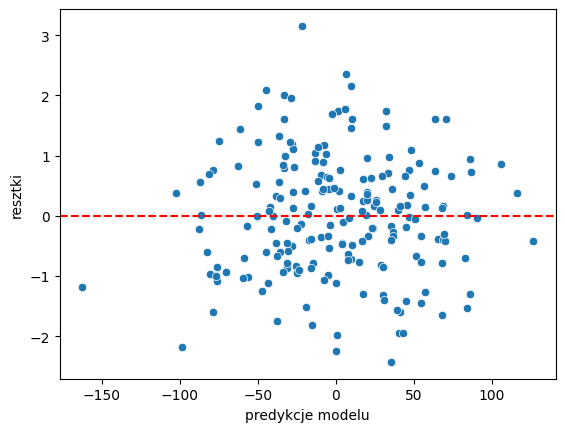

In [29]:
def plot_residuals(model, X, y):
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    sns.scatterplot(x = y_pred, y = residuals)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("predykcje modelu")
    plt.ylabel("resztki")
    
plot_residuals(model, X,y)

widac homoskedastycznosc 

Homoskedastyczność (Stan idealny): Kropki są rozrzucone losowo i równomiernie. Tworzą kształt przypominający poziomy prostokąt. Szerokość pasma błędu jest taka sama dla małych i dużych prognoz.
Heteroskedastyczność (Problem): Kropki tworzą wyraźny wzorzec, najczęściej kształt lejka, trąbki lub wachlarza. Na początku wykresu rozrzut jest minimalny, a im dalej w prawo, tym odległości błędu od linii zero stają się coraz większe (lub odwrotnie)